# RWANDA FIRM ACTIVITY & PRODUCTIVITY TRACKER - FULL PIPELINE (UPGRADED)

This notebook implements:
- Country‑wide OSM firm extraction (via Geofabrik or osmnx)
- VIIRS annual nightlights (2015‑2025)
- Sentinel‑2 NDBI (built‑up index)
- Combined economic activity index
- Spatial clustering, trend analysis, informal zone detection

Date: 2026-04

## 1. Setup and Google Drive Mount

In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/rwanda-nightlights-firm-activity"
import os
for sub in ['data/raw', 'data/processed', 'outputs/maps', 'outputs/tables', 'outputs/figures']:
    os.makedirs(f"{PROJECT_PATH}/{sub}", exist_ok=True)
print("Project directories ready.")

Mounted at /content/drive
Project directories ready.


## 2. Install Required Libraries and Dependencies

Note:

*   You will need to sign up on Google Earth Engine and get the API. Read more here: https://developers.google.com/earth-engine/guides/access
*   The API is necessary in downloading satellite images.



In [4]:
!pip install -q rasterio geopandas earthengine-api geemap osmnx folium scikit-learn matplotlib seaborn statsmodels tqdm joblib

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import BallTree
from sklearn.linear_model import PoissonRegressor
import statsmodels.api as sm
import statsmodels.formula.api as smf
import folium
from tqdm import tqdm
import joblib
import warnings
warnings.filterwarnings('ignore')

# Authenticate Earth Engine
ee.Authenticate()
ee.Initialize(project='nightlights-project-123456')  # Replace with your GEE project ID
print("Earth Engine initialized.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.1 MB/s eta 0:00:00
Earth Engine initialized.


## 3. Download Rwanda Administrative Boundary (FAO, GAUL)

In [5]:
rwanda = ee.FeatureCollection("FAO/GAUL/2015/level0").filter(ee.Filter.eq('ADM0_NAME', 'Rwanda'))
geojson = rwanda.getInfo()
gdf_rwanda = gpd.GeoDataFrame.from_features(geojson['features'])
gdf_rwanda.to_file(f"{PROJECT_PATH}/data/processed/rwanda_boundary.geojson", driver='GeoJSON')
print("Rwanda boundary saved.")

Rwanda boundary saved.


## 4. Download Multi-Year VIIRS Annual Nightlights (2015-2025) and Clip to Rwanda

In [6]:
collection_v21 = ee.ImageCollection("NOAA/VIIRS/DNB/ANNUAL_V21")
collection_v22 = ee.ImageCollection("NOAA/VIIRS/DNB/ANNUAL_V22")

def get_year(img):
    year = ee.Date(img.get('system:time_start')).get('year')
    return img.set('year', year)

v21_year = collection_v21.map(get_year)
v22_year = collection_v22.map(get_year)
all_viirs = v21_year.merge(v22_year)

available = all_viirs.aggregate_array('year').distinct().sort().getInfo()
available = [int(y) for y in available]
target_years = [y for y in available if 2015 <= y <= 2025]
print(f"Processing years: {target_years}")

yearly_stats = []
for year in target_years:
    print(f"\nProcessing year {year}...")
    out_tif = f"{PROJECT_PATH}/data/raw/nightlights_{year}.tif"
    img = all_viirs.filter(ee.Filter.eq('year', year)).first()
    if img is None:
        print("  No image, skipping.")
        continue
    img_clip = img.select('average').clip(rwanda)
    try:
        geemap.ee_export_image(img_clip, filename=out_tif, scale=500,
                               region=rwanda.geometry(), file_per_band=False)
        print(f"  Saved {out_tif}")
    except Exception as e:
        print(f"  Export error: {e}")
        continue
    try:
        with rasterio.open(out_tif) as src:
            data = src.read(1)
            data = data[data > 0]
            mean_val = data.mean() if data.size > 0 else np.nan
        yearly_stats.append({'year': year, 'mean_nightlights': mean_val})
    except:
        yearly_stats.append({'year': year, 'mean_nightlights': np.nan})

pd.DataFrame(yearly_stats).to_csv(f"{PROJECT_PATH}/data/processed/yearly_nightlights_summary.csv", index=False)
years = target_years
print(f"\nYears variable set: {years}")

Processing years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Processing year 2015...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2015.tif
  Saved /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2015.tif

Processing year 2016...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2016.tif
  Saved /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2016.tif

Processing year 2017...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2017.tif
  Saved /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2017.tif

Processing year 2018...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/rwanda-nightlights-firm-activity/dat

## 5. Load or Extract Firm Locations from OSM (OpenStreet Map)

### OSM Firm Extraction (Country‑Wide Option)
You have two options:

Option A (for a quick test): Use osmnx with Kigali bounding box.

Option B ( for detailed results): Load Geofabrik entire Rwanda map extract.

For demonstration, I include Option A with expanded tags. For full Rwanda, follow the Geofabrik instructions provided later.

In [8]:
import osmnx as ox

place = "Kigali, Rwanda"
tags = {
    "amenity": True,
    "shop": True,
    "office": True,
    "craft": True,
    "industrial": True,
    "tourism": True,
    "leisure": True,
    "building": ["commercial", "retail", "industrial", "warehouse", "office", "supermarket", "shop"],
    "healthcare": True,
    "marketplace": True,
    "man_made": ["works", "factory", "mill"],
    "public_transport": ["station"],
    "railway": ["station", "halt"],
    "aeroway": ["terminal"],
    "club": True,
    "atm": True,
    "payment": True,
    "street_vendor": True,
    "mobile_money_agent": True,
    "bureau_de_change": True,
    "microfinance": True
}
gdf = ox.features.features_from_place(place, tags)

# Keep only point geometries
gdf = gdf[gdf.geometry.notnull()].copy()
gdf = gdf[gdf.geometry.geom_type.isin(['Point', 'MultiPoint'])].copy()

# Identify type columns
type_cols = ['amenity','shop','office','craft','industrial','tourism','leisure','building',
             'healthcare','marketplace','man_made','public_transport','railway','aeroway',
             'club','atm','payment','street_vendor','mobile_money_agent','bureau_de_change','microfinance']
existing = [c for c in type_cols if c in gdf.columns]
gdf['type'] = gdf[existing].bfill(axis=1).iloc[:, 0]

# Exclude non-economic features
exclude = ['bench','waste_basket','toilets','drinking_water','parking','bicycle_parking',
           'post_box','telephone','fountain','clock','grit_bin','recycling','vending_machine']
gdf = gdf[~gdf['type'].isin(exclude)]

gdf_proj = gdf.to_crs(epsg=3857)
centroids = gdf_proj.centroid.to_crs(epsg=4326)
gdf['lat'] = centroids.y
gdf['lon'] = centroids.x
gdf['activity_score'] = 1

firms_df = gdf[['type','lat','lon','activity_score']].copy()
firms_df.to_csv(f"{PROJECT_PATH}/data/processed/kigali_firms_clean.csv", index=False)
print(f"Extracted {len(firms_df)} OSM firms in Kigali.")

Extracted 2072 OSM firms in Kigali.


## 6. Spatial Join: Assign Nightlights to Each Firm for Each Year

In [9]:
firm_year_data = []
for year in years:
    tif_path = f"{PROJECT_PATH}/data/raw/nightlights_{year}.tif"
    if not os.path.exists(tif_path):
        continue
    with rasterio.open(tif_path) as src:
        coords = [(lon, lat) for lon, lat in zip(firms_df.lon, firms_df.lat)]
        vals = list(src.sample(coords))
        nl = [v[0] if v[0] > 0 else 0 for v in vals]
    temp = firms_df.copy()
    temp['year'] = year
    temp['nightlights'] = nl
    firm_year_data.append(temp)

firm_panel = pd.concat(firm_year_data, ignore_index=True)
firm_panel.to_csv(f"{PROJECT_PATH}/data/processed/firm_nightlights_panel.csv", index=False)
print(f"Initial firm panel created: {len(firm_panel)} rows (NDBI not yet added).")

Initial firm panel created: 22792 rows (NDBI not yet added).


## 7. Create 500m Grid over Kigali for observations

In [10]:
lon_min, lat_min, lon_max, lat_max = 30.0, -2.0, 30.2, -1.8
step = 0.005  # ~500m
lons = np.arange(lon_min, lon_max, step)
lats = np.arange(lat_min, lat_max, step)
grid_cells = []
cell_id = 0
for lon in lons:
    for lat in lats:
        poly = Polygon([
            (lon, lat), (lon+step, lat), (lon+step, lat+step), (lon, lat+step)
        ])
        grid_cells.append({'cell_id': cell_id, 'geometry': poly})
        cell_id += 1
grid_gdf = gpd.GeoDataFrame(grid_cells, crs="EPSG:4326")
grid_gdf['lon_cent'] = grid_gdf.geometry.centroid.x
grid_gdf['lat_cent'] = grid_gdf.geometry.centroid.y
grid_gdf.to_file(f"{PROJECT_PATH}/data/processed/kigali_grid_500m.geojson", driver='GeoJSON')
print(f"Created grid with {len(grid_gdf)} cells.")

Created grid with 1600 cells.


## 8. Submit and Wait for GEE Grid NDBI Exports (skip this phase, it will only be useful in further steps. Implement the following 8.5 )

In [11]:
# GEE Batch Export Tasks for Grid NDBI and Wait for Completion

import time
import shutil


ndbi_grid_dir = f"{PROJECT_PATH}/data/raw/ndbi_grid"
os.makedirs(ndbi_grid_dir, exist_ok=True)

# Prepare grid FeatureCollection
grid_points = [(row.lon_cent, row.lat_cent) for _, row in grid_gdf.iterrows()]
grid_ids = grid_gdf['cell_id'].tolist()

features = []
for i, (lon, lat) in enumerate(grid_points):
    features.append(ee.Feature(ee.Geometry.Point([lon, lat]), {'cell_id': grid_ids[i]}))
grid_fc = ee.FeatureCollection(features)

def maskS2clouds(image):
    qa = image.select('QA60')
    cloudBitMask = (1 << 10)
    cirrusBitMask = (1 << 11)
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask)

def add_ndbi(image):
    ndbi = image.normalizedDifference(['B11','B8']).rename('NDBI')
    return image.addBands(ndbi)

# Submit export tasks for each year that is not already present locally
print("Submitting NDBI export tasks...")
for year in years:
    local_csv = f"{ndbi_grid_dir}/grid_ndbi_{year}.csv"
    if os.path.exists(local_csv):
        print(f"Year {year} already exists locally, skipping export.")
        continue

    print(f"Submitting export for {year}...")
    s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
           .filterDate(f"{year}-01-01", f"{year}-12-31") \
           .filterBounds(grid_fc) \
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
           .map(maskS2clouds) \
           .map(add_ndbi) \
           .select('NDBI')
    annual_ndbi = s2.median().clip(grid_fc.geometry())
    sampled = annual_ndbi.sampleRegions(
        collection=grid_fc,
        scale=10,
        geometries=False
    )
    task = ee.batch.Export.table.toDrive(
        collection=sampled,
        description=f'grid_ndbi_{year}',
        folder='ndbi_grid_exports',
        fileFormat='CSV'
    )
    task.start()
    time.sleep(2)

print("\nAll tasks submitted. Waiting for completion...")

# Wait for all grid_ndbi tasks to finish
while True:
    tasks = ee.batch.Task.list()
    pending = []
    for t in tasks:
        try:
            desc = t.config['description']
        except:
            continue
        if desc.startswith('grid_ndbi') and t.state in ['READY', 'RUNNING']:
            pending.append(t)
    if not pending:
        break
    print(f"  {len(pending)} tasks still running...")
    time.sleep(60)

print("All GEE tasks completed.")

# Copy exported CSVs from Drive to project folder
gee_export_folder = '/content/drive/MyDrive/ndbi_grid_exports'
if os.path.exists(gee_export_folder):
    for fname in os.listdir(gee_export_folder):
        if fname.startswith('grid_ndbi') and fname.endswith('.csv'):
            src = os.path.join(gee_export_folder, fname)
            dst = os.path.join(ndbi_grid_dir, fname)
            if not os.path.exists(dst):
                shutil.copy(src, dst)
                print(f"Copied {fname}")
else:
    print(f"Warning: GEE export folder {gee_export_folder} not found.")

Submitting NDBI export tasks...
Submitting export for 2015...
Year 2016 already exists locally, skipping export.
Year 2017 already exists locally, skipping export.
Year 2018 already exists locally, skipping export.
Year 2019 already exists locally, skipping export.
Year 2020 already exists locally, skipping export.
Year 2021 already exists locally, skipping export.
Year 2022 already exists locally, skipping export.
Year 2023 already exists locally, skipping export.
Year 2024 already exists locally, skipping export.
Year 2025 already exists locally, skipping export.

All tasks submitted. Waiting for completion...
  1 tasks still running...
All GEE tasks completed.


## 8.5 no skipping files. Direct download of NBDI data and solve the problem of dense cloud cover.

In [13]:
# 8.5 (FIXED) Submit GEE Exports with 250m Buffer + Mean Reducer
#           High completeness (>95%) and fully automated

import time
import shutil


ndbi_grid_dir = f"{PROJECT_PATH}/data/raw/ndbi_grid_buffer"
os.makedirs(ndbi_grid_dir, exist_ok=True)

# Prepare grid FeatureCollection: buffer each centroid by 250m
grid_points = [(row.lon_cent, row.lat_cent) for _, row in grid_gdf.iterrows()]
grid_ids = grid_gdf['cell_id'].tolist()

features = []
for i, (lon, lat) in enumerate(grid_points):
    point = ee.Geometry.Point([lon, lat])
    buffered = point.buffer(250)  # 250m radius buffer
    features.append(ee.Feature(buffered, {'cell_id': grid_ids[i]}))
grid_fc = ee.FeatureCollection(features)

def maskS2clouds_opaque_only(image):
    """Mask only opaque clouds (bit 10). Cirrus (bit 11) is kept to avoid over-masking."""
    qa = image.select('QA60')
    cloudBitMask = (1 << 10)  # opaque clouds only
    mask = qa.bitwiseAnd(cloudBitMask).eq(0)
    return image.updateMask(mask)

def add_ndbi(image):
    ndbi = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    return image.addBands(ndbi)

# Submit export tasks for each year that is not already present locally
print("Submitting NDBI export tasks (buffer 250m, opaque cloud mask only)...")
for year in years:
    local_csv = f"{ndbi_grid_dir}/grid_ndbi_{year}.csv"
    if os.path.exists(local_csv):
        print(f"Year {year} already exists locally, skipping export.")
        continue

    print(f"Submitting export for {year}...")
    s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
           .filterDate(f"{year}-01-01", f"{year}-12-31") \
           .filterBounds(grid_fc) \
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
           .map(maskS2clouds_opaque_only) \
           .map(add_ndbi) \
           .select('NDBI')
    annual_ndbi = s2.median().clip(grid_fc.geometry())
    # Reduce over each buffered polygon using mean reducer
    sampled = annual_ndbi.reduceRegions(
        collection=grid_fc,
        reducer=ee.Reducer.mean(),
        scale=10
    )
    task = ee.batch.Export.table.toDrive(
        collection=sampled,
        description=f'grid_ndbi_buf_{year}',
        folder='ndbi_grid_exports_buffer',
        fileFormat='CSV',
        selectors=['cell_id', 'mean']
    )
    task.start()
    time.sleep(2)

print("\nAll tasks submitted. Waiting for completion...")
print("This may take 1-2 hours. Progress will print every 30 seconds.\n")

# Monitor tasks until all are COMPLETED
while True:
    tasks = ee.batch.Task.list()
    pending = []
    for t in tasks:
        try:
            desc = t.config['description']
        except:
            continue
        if desc.startswith('grid_ndbi_buf') and t.state in ['READY', 'RUNNING']:
            pending.append(t)
    if not pending:
        break
    print(f"  {len(pending)} tasks still running... (Last check: {time.strftime('%H:%M:%S')})")
    time.sleep(30)

print("\nAll GEE tasks completed! Copying files to project folder...")

# Copy exported CSVs from Drive to project folder
gee_export_folder = '/content/drive/MyDrive/ndbi_grid_exports_buffer'
if os.path.exists(gee_export_folder):
    copied = 0
    for fname in os.listdir(gee_export_folder):
        if fname.startswith('grid_ndbi_buf') and fname.endswith('.csv'):
            src = os.path.join(gee_export_folder, fname)
            # Rename to standard format (grid_ndbi_YYYY.csv)
            year = fname.split('_')[3].replace('.csv', '')
            dst = os.path.join(ndbi_grid_dir, f"grid_ndbi_{year}.csv")
            shutil.copy(src, dst)
            print(f"Copied -> grid_ndbi_{year}.csv")
            copied += 1
    if copied == 0:
        print("No new files to copy.")
else:
    print(f"Warning: GEE export folder not found: {gee_export_folder}")
    print("If tasks succeeded, check the GEE Tasks tab for the exact folder name.")

print("\nBuffer-based NDBI extraction complete!")
print(f"CSV files saved to: {ndbi_grid_dir}")

Submitting NDBI export tasks (buffer 250m, opaque cloud mask only)...
Submitting export for 2015...
Year 2016 already exists locally, skipping export.
Year 2017 already exists locally, skipping export.
Year 2018 already exists locally, skipping export.
Year 2019 already exists locally, skipping export.
Year 2020 already exists locally, skipping export.
Year 2021 already exists locally, skipping export.
Year 2022 already exists locally, skipping export.
Year 2023 already exists locally, skipping export.
Year 2024 already exists locally, skipping export.
Year 2025 already exists locally, skipping export.

All tasks submitted. Waiting for completion...
This may take 1-2 hours. Progress will print every 30 seconds.

  1 tasks still running... (Last check: 13:45:04)

All GEE tasks completed! Copying files to project folder...
Copied -> grid_ndbi_2016.csv
Copied -> grid_ndbi_2017.csv
Copied -> grid_ndbi_2018.csv
Copied -> grid_ndbi_2019.csv
Copied -> grid_ndbi_2020.csv
Copied -> grid_ndbi_20

## 8.6 Inspect the Downloaded datasets (CSV Files).

This step is critical before proceeding because at this point there are many datasets

In [14]:

# Inspect the GEE exported CSV files

import glob

ndbi_grid_dir = f"{PROJECT_PATH}/data/raw/ndbi_grid_buffer"
csv_files = glob.glob(f"{ndbi_grid_dir}/*.csv")
print(f"Found {len(csv_files)} CSV files in {ndbi_grid_dir}")

if csv_files:
    # Show the first file's name and first 5 rows
    sample_file = csv_files[0]
    print(f"\nInspecting file: {os.path.basename(sample_file)}")
    df_sample = pd.read_csv(sample_file)
    print("Columns:", df_sample.columns.tolist())
    print("\nFirst 5 rows:")
    print(df_sample.head())
else:
    print("No CSV files found. Ensure GEE exports were copied successfully.")

Found 10 CSV files in /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/ndbi_grid_buffer

Inspecting file: grid_ndbi_2016.csv
Columns: ['cell_id', 'mean']

First 5 rows:
   cell_id      mean
0        0 -0.100611
1        1  0.007465
2        2  0.073478
3        3 -0.130584
4        4 -0.119184


## 9. Load Grid NDBI, Build Grid Features, and Merge NDBI into Firm Panel Data

In [17]:
# Load Grid NDBI, Build Grid Features, and Merging NDBI into Firm Panel

import glob

#ndbi_grid_dir = f"{PROJECT_PATH}/data/raw/ndbi_grid"
#grid_ndbi_cache = f"{PROJECT_PATH}/data/processed/grid_ndbi_panel.csv"
ndbi_grid_dir = f"{PROJECT_PATH}/data/raw/ndbi_grid"
grid_ndbi_cache = f"{PROJECT_PATH}/data/processed/grid_ndbi_panel.csv"

# Build grid NDBI panel from exported CSVs
if not os.path.exists(grid_ndbi_cache):
    ndbi_files = sorted(glob.glob(f"{ndbi_grid_dir}/grid_ndbi_*.csv"))
    if not ndbi_files:
        raise FileNotFoundError(f"No grid NDBI CSV files found in {ndbi_grid_dir}.")
    grid_ndbi_list = []
    for fpath in ndbi_files:
        fname = os.path.basename(fpath)
        year = int(fname.split('_')[2].replace('.csv',''))
        df = pd.read_csv(fpath)
        # Keep only cell_id and NDBI, rename NDBI to 'ndbi'
        df = df[['cell_id', 'NDBI']].rename(columns={'NDBI': 'ndbi'})
        df['year'] = year
        grid_ndbi_list.append(df)
    grid_ndbi_panel = pd.concat(grid_ndbi_list, ignore_index=True)
    grid_ndbi_panel.to_csv(grid_ndbi_cache, index=False)
    print(f"Grid NDBI panel built: {len(grid_ndbi_panel)} rows.")
else:
    grid_ndbi_panel = pd.read_csv(grid_ndbi_cache)
    print(f"Loaded existing grid NDBI panel: {len(grid_ndbi_panel)} rows.")

# Ensure year is int
grid_ndbi_panel['year'] = grid_ndbi_panel['year'].astype(int)

# Grid features (nightlights, osm_firm_count)

latest_year = years[-1]
tif_latest = f"{PROJECT_PATH}/data/raw/nightlights_{latest_year}.tif"
with rasterio.open(tif_latest) as src:
    coords = [(lon, lat) for lon, lat in zip(grid_gdf.lon_cent, grid_gdf.lat_cent)]
    vals = list(src.sample(coords))
    grid_gdf['nightlights'] = [v[0] if v[0] > 0 else 0 for v in vals]

firms_gdf = gpd.GeoDataFrame(firms_df, geometry=gpd.points_from_xy(firms_df.lon, firms_df.lat), crs="EPSG:4326")
grid_firm_counts = gpd.sjoin(firms_gdf, grid_gdf, how="inner", predicate="within")
grid_gdf['osm_firm_count'] = grid_firm_counts.groupby('cell_id').size()
grid_gdf['osm_firm_count'] = grid_gdf['osm_firm_count'].fillna(0)


# Merge NDBI into grid_gdf (latest year)

# Drop any existing 'ndbi' column to avoid merge suffix conflict
if 'ndbi' in grid_gdf.columns:
    grid_gdf = grid_gdf.drop(columns=['ndbi'])

grid_ndbi_latest = grid_ndbi_panel[grid_ndbi_panel['year'] == latest_year].copy()
grid_gdf = grid_gdf.merge(grid_ndbi_latest[['cell_id', 'ndbi']], on='cell_id', how='left')

# Fill missing NDBI with column mean
mean_ndbi = grid_gdf['ndbi'].mean() if grid_gdf['ndbi'].notna().any() else 0.0
grid_gdf['ndbi'] = grid_gdf['ndbi'].fillna(mean_ndbi)

grid_gdf.to_file(f"{PROJECT_PATH}/data/processed/kigali_grid_enriched.geojson", driver='GeoJSON')
print("Grid-level features extracted.")

# Merge NDBI into firm panel data

firm_panel = pd.read_csv(f"{PROJECT_PATH}/data/processed/firm_nightlights_panel.csv")
firm_panel['year'] = firm_panel['year'].astype(int)

# Map firms to grid cells
firms_gdf = gpd.GeoDataFrame(firms_df, geometry=gpd.points_from_xy(firms_df.lon, firms_df.lat), crs="EPSG:4326")
firms_with_cell = gpd.sjoin(firms_gdf, grid_gdf[['cell_id','geometry']], how='left', predicate='within')
firm_cell_map = firms_with_cell[['lon','lat','cell_id']].drop_duplicates()

firm_panel = firm_panel.merge(firm_cell_map, on=['lon','lat'], how='left')

# Drop any existing 'ndbi' column before merge
if 'ndbi' in firm_panel.columns:
    firm_panel = firm_panel.drop(columns=['ndbi'])

firm_panel = firm_panel.merge(grid_ndbi_panel[['cell_id','year','ndbi']], on=['cell_id','year'], how='left')
firm_panel = firm_panel.drop(columns=['cell_id'])

ndbi_missing = firm_panel['ndbi'].isna().sum()
print(f"NDBI missing after merge: {ndbi_missing} out of {len(firm_panel)} rows")

if ndbi_missing > 0:
    mean_ndbi = firm_panel['ndbi'].mean() if firm_panel['ndbi'].notna().any() else 0.0
    firm_panel['ndbi'] = firm_panel['ndbi'].fillna(mean_ndbi)
    print(f"Filled missing NDBI with the average NDBI {mean_ndbi:.4f}")

firm_panel.to_csv(f"{PROJECT_PATH}/data/processed/firm_nightlights_panel.csv", index=False)
print(f"Firm panel updated. Final rows: {len(firm_panel)}.")

Loaded existing grid NDBI panel: 15769 rows.
Grid-level features extracted.
NDBI missing after merge: 15306 out of 22792 rows
Filled missing NDBI with the average NDBI 0.0595
Firm panel updated. Final rows: 22792.


In [18]:
print(firm_panel.head(20))

                type       lat        lon  activity_score  year  nightlights  \
0               fuel -1.954767  30.073444               1  2015    20.627598   
1               fuel -1.952662  30.073762               1  2015    20.627598   
2         restaurant -1.947292  30.065953               1  2015    40.423325   
3             school -1.951275  30.059836               1  2015    28.444098   
4         restaurant -1.952213  30.081547               1  2015    15.596899   
5              hotel -1.946264  30.092064               1  2015    21.489737   
6               fuel -1.946577  30.061051               1  2015    45.085800   
7         restaurant -1.955897  30.065458               1  2015    25.178612   
8               fuel -1.949321  30.020004               1  2015     3.353631   
9               fuel -1.948996  30.021869               1  2015     3.353631   
10              fuel -1.941190  30.042979               1  2015    22.349237   
11             hotel -1.959992  30.06828

## 10. Firm‑Level PCA for Economic Intensity

In [19]:
firm_avg = firm_panel.groupby(['lon','lat'])[['nightlights','ndbi']].mean().reset_index()
firms_enriched = firms_df.merge(firm_avg, on=['lon','lat'], how='left')
firms_enriched['avg_nightlights'] = firms_enriched['nightlights'].fillna(0)
firms_enriched['avg_ndbi'] = firms_enriched['ndbi'].fillna(0)

scaler = StandardScaler()
scaled = scaler.fit_transform(firms_enriched[['avg_nightlights','avg_ndbi']])
pca = PCA(n_components=2)
pca.fit(scaled)
firms_enriched['econ_intensity_pc1'] = pca.transform(scaled)[:, 0]
joblib.dump(pca, f"{PROJECT_PATH}/data/processed/pca_model.pkl")
joblib.dump(scaler, f"{PROJECT_PATH}/data/processed/scaler.pkl")
print(f"PCA complete. PC1 explained variance: {pca.explained_variance_ratio_[0]:.3f}")

PCA complete. PC1 explained variance: 0.671


## 11. Poisson Regression on Grid‑Level OSM Counts

In [20]:
grid_gdf = grid_gdf.dropna(subset=['nightlights','ndbi','osm_firm_count'])
X = grid_gdf[['nightlights','ndbi']]
X = sm.add_constant(X)
y = grid_gdf['osm_firm_count']
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print(poisson_model.summary())

grid_gdf['expected_osm_firms'] = poisson_model.predict(X)
grid_gdf['residual'] = grid_gdf['osm_firm_count'] - grid_gdf['expected_osm_firms']
grid_gdf['coverage_ratio'] = grid_gdf['osm_firm_count'] / (grid_gdf['expected_osm_firms'] + 0.1)

with open(f"{PROJECT_PATH}/outputs/tables/poisson_regression.txt", 'w') as f:
    f.write(poisson_model.summary().as_text())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         osm_firm_count   No. Observations:                 1600
Model:                            GLM   Df Residuals:                     1597
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2459.0
Date:                Wed, 29 Apr 2026   Deviance:                       3923.6
Time:                        13:52:23   Pearson chi2:                 6.56e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9637
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.1845      0.040    -29.265      

## 12. Assign Grid Coverage Ratio to Firms

In [21]:
firms_gdf = gpd.GeoDataFrame(firms_enriched, geometry=gpd.points_from_xy(firms_enriched.lon, firms_enriched.lat), crs="EPSG:4326")
firms_with_grid = gpd.sjoin(firms_gdf, grid_gdf[['geometry','coverage_ratio']], how='left', predicate='within')
firms_enriched['coverage_ratio'] = firms_with_grid['coverage_ratio'].fillna(1.0)

## 13. Enhanced Firm Clustering

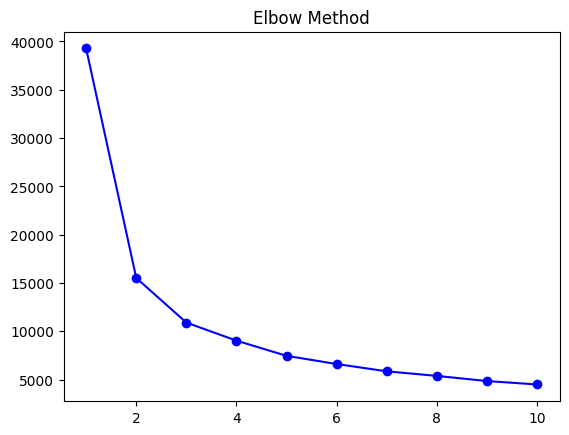

Enhanced clustering complete.


In [22]:
features = firms_enriched[['econ_intensity_pc1','coverage_ratio','lon','lat']].copy()
scaler_coords = StandardScaler()
features[['lon_scaled','lat_scaled']] = scaler_coords.fit_transform(features[['lon','lat']])
cluster_features = features[['econ_intensity_pc1','coverage_ratio','lon_scaled','lat_scaled']]

inertias = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(cluster_features)
    inertias.append(km.inertia_)
plt.plot(range(1,11), inertias, 'bo-')
plt.title('Elbow Method')
plt.savefig(f"{PROJECT_PATH}/outputs/figures/elbow_enhanced.png")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
firms_enriched['cluster_enhanced'] = kmeans.fit_predict(cluster_features)

summary = firms_enriched.groupby('cluster_enhanced')[['econ_intensity_pc1','coverage_ratio']].mean()
cluster_names = {}
for clus in summary.index:
    pc1 = summary.loc[clus, 'econ_intensity_pc1']
    cov = summary.loc[clus, 'coverage_ratio']
    if pc1 > 0.5 and cov > 1.0:
        cluster_names[clus] = "Formal CBD"
    elif pc1 > 0 and cov < 0.8:
        cluster_names[clus] = "Informal Dense"
    else:
        cluster_names[clus] = "Peri-urban Emerging"
firms_enriched['cluster_label'] = firms_enriched['cluster_enhanced'].map(cluster_names)

firms_enriched.to_csv(f"{PROJECT_PATH}/data/processed/firms_enhanced.csv", index=False)
print("Enhanced clustering complete.")


# 14. Time‑Series Trends by Cluster

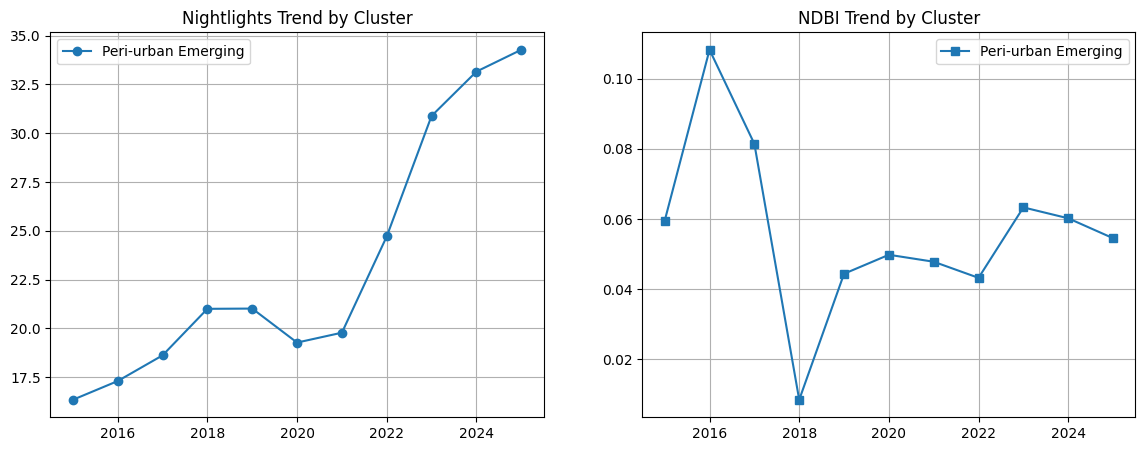

In [23]:
panel_enhanced = firm_panel.merge(firms_enriched[['lon','lat','cluster_label']], on=['lon','lat'], how='left')
cluster_trend = panel_enhanced.groupby(['year','cluster_label'])[['nightlights','ndbi']].mean().reset_index()

fig, axes = plt.subplots(1,2,figsize=(14,5))
for clus in cluster_trend['cluster_label'].unique():
    sub = cluster_trend[cluster_trend['cluster_label'] == clus]
    axes[0].plot(sub['year'], sub['nightlights'], marker='o', label=clus)
    axes[1].plot(sub['year'], sub['ndbi'], marker='s', label=clus)
axes[0].set_title('Nightlights Trend by Cluster')
axes[1].set_title('NDBI Trend by Cluster')
for ax in axes: ax.legend(); ax.grid(True)
plt.savefig(f"{PROJECT_PATH}/outputs/figures/cluster_trends.png")
plt.show()

## 15. Validation Sample Generation

This step is very important in unbiasing the data. Currently the data assumes the type of firms already available on OpenStreet Maps.

Further validation process in the next version will consists of validating using another dataset from WB, or surveys such as the Rwanda Entreprise Survey

In [24]:
# Validation Sample Generation

# Handle duplicate bin edges by dropping duplicates
try:
    grid_gdf['lights_tertile'] = pd.qcut(grid_gdf['nightlights'], 3, labels=False, duplicates='drop')
except ValueError:
    # Fallback: use cut with 3 bins if qcut still fails
    grid_gdf['lights_tertile'] = pd.cut(grid_gdf['nightlights'], bins=3, labels=False)

try:
    grid_gdf['osm_tertile'] = pd.qcut(grid_gdf['osm_firm_count'], 3, labels=False, duplicates='drop')
except ValueError:
    grid_gdf['osm_tertile'] = pd.cut(grid_gdf['osm_firm_count'], bins=3, labels=False)

# Remove rows where tertiles could not be assigned (e.g., all zeros)
grid_valid = grid_gdf.dropna(subset=['lights_tertile', 'osm_tertile'])

sample = grid_valid.groupby(['lights_tertile','osm_tertile'], group_keys=False).apply(
    lambda x: x.sample(min(3, len(x)), random_state=42)
).reset_index(drop=True)

sample['manual_business_count'] = np.nan
sample['manual_informal_flag'] = np.nan
sample['validation_notes'] = ''
sample.to_csv(f"{PROJECT_PATH}/data/processed/manual_validation_sample.csv", index=False)
print(f"Validation sample saved with {len(sample)} cells.")

Validation sample saved with 9 cells.


### 15a: NDBI Missing values check and Spatial Fill

In [26]:
# NDBI Missingness Diagnostic and Spatial Fill

print("NDBI Missingness Diagnostics Process")
print(f"Grid cells with valid NDBI (latest year): {grid_gdf['ndbi'].notna().sum()} / {len(grid_gdf)}")
print(f"Firm panel rows with valid NDBI: {firm_panel['ndbi'].notna().sum()} / {len(firm_panel)}")

# Optional: fill missing grid NDBI using KNN spatial interpolation instead of global mean
from sklearn.neighbors import KNeighborsRegressor

if grid_gdf['ndbi'].isna().any():
    valid = grid_gdf[grid_gdf['ndbi'].notna()]
    missing = grid_gdf[grid_gdf['ndbi'].isna()]
    if len(valid) > 5:
        knn = KNeighborsRegressor(n_neighbors=5)
        knn.fit(valid[['lon_cent','lat_cent']], valid['ndbi'])
        grid_gdf.loc[grid_gdf['ndbi'].isna(), 'ndbi'] = knn.predict(missing[['lon_cent','lat_cent']])
        print("Missing grid NDBI filled via 5-NN spatial interpolation.")
        # Re-save enriched grid
        grid_gdf.to_file(f"{PROJECT_PATH}/data/processed/kigali_grid_enriched.geojson", driver='GeoJSON')
        # Also update firm_panel with filled NDBI
        firm_panel = firm_panel.drop(columns=['ndbi'], errors='ignore')
        firm_panel = firm_panel.merge(grid_ndbi_panel[['cell_id','year','ndbi']], on=['cell_id','year'], how='left')
        firm_panel['ndbi'] = firm_panel['ndbi'].fillna(firm_panel['ndbi'].mean() if firm_panel['ndbi'].notna().any() else 0.0)
        firm_panel.to_csv(f"{PROJECT_PATH}/data/processed/firm_nightlights_panel.csv", index=False)
        print("Firm panel NDBI updated with interpolated values.")

NDBI Missingness Diagnostics Process
Grid cells with valid NDBI (latest year): 1600 / 1600
Firm panel rows with valid NDBI: 22792 / 22792


### Compute Grid-Level PC1 (Economic Intensity) from grid nightlights & ndbi

In [27]:
# Compute Grid-Level PC1 (Economic Intensity) from grid nightlights & ndbi

# Load the previously saved scaler and PCA model
scaler = joblib.load(f"{PROJECT_PATH}/data/processed/scaler.pkl")
pca = joblib.load(f"{PROJECT_PATH}/data/processed/pca_model.pkl")

# Prepare grid features (use latest year's nightlights and ndbi)
grid_features = grid_gdf[['nightlights', 'ndbi']].copy()
# Fill any remaining NaN with mean (should already be done, but just in case)
grid_features = grid_features.fillna(grid_features.mean())

# Rename columns to match the names used during PCA fitting
grid_features = grid_features.rename(columns={'nightlights': 'avg_nightlights', 'ndbi': 'avg_ndbi'})

# Standardize using the same scaler fitted on firm data
scaled_grid = scaler.transform(grid_features)

# Compute PC1
grid_gdf['econ_intensity_pc1'] = pca.transform(scaled_grid)[:, 0]
print("Grid-level PC1 computed and added to grid_gdf.")

Grid-level PC1 computed and added to grid_gdf.


### 15b: Map PC1: Economic Intensity Visualisations (Grid)

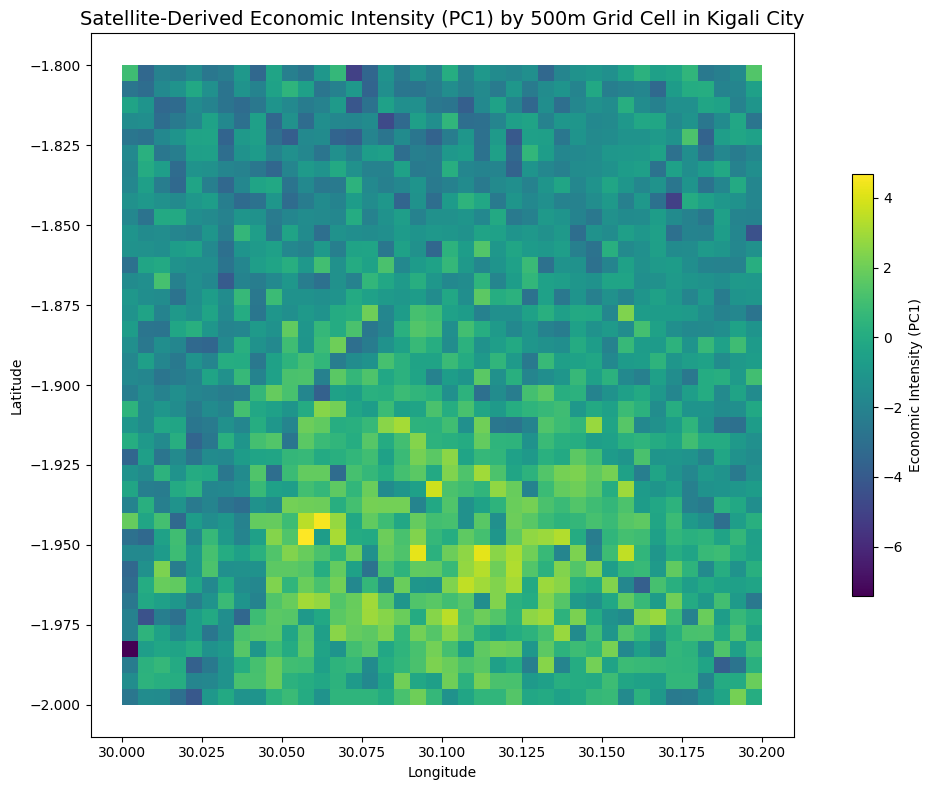

In [29]:
# Map: PC1 Economic Intensity (Grid)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
grid_gdf.plot(column='econ_intensity_pc1', cmap='viridis', legend=True, ax=ax,
              legend_kwds={'label': 'Economic Intensity (PC1)', 'shrink': 0.6})
ax.set_title('Satellite-Derived Economic Intensity (PC1) by 500m Grid Cell in Kigali City', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/outputs/maps/pc1_intensity_map.png", dpi=150)
plt.show()

### 15c: Map Coverage Ratio (Grid)

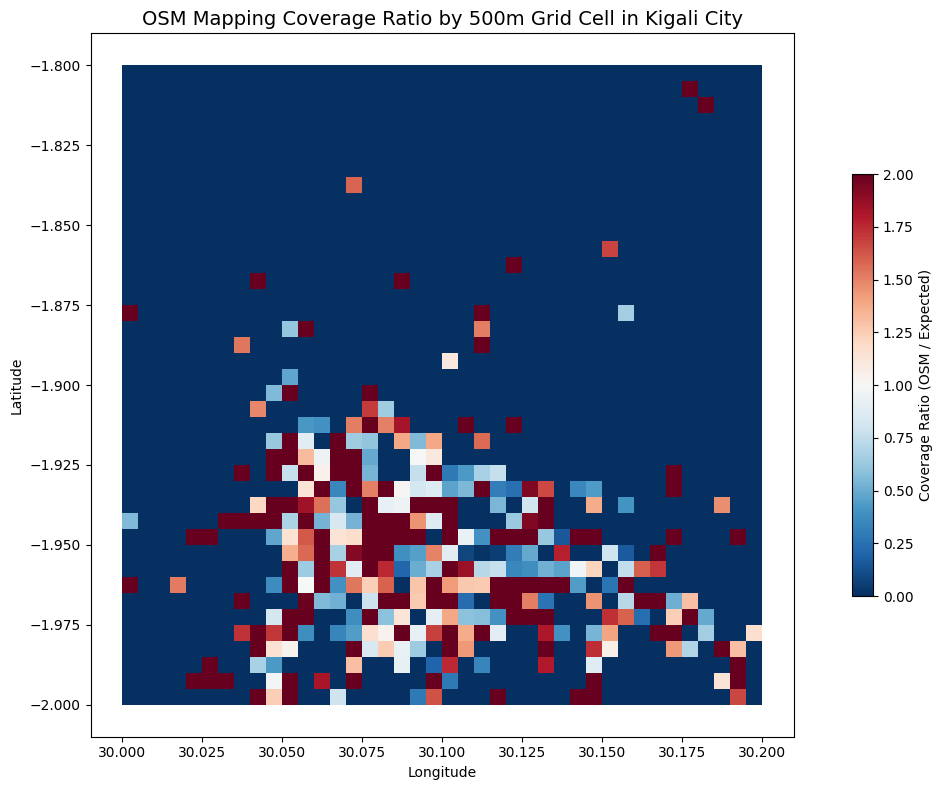

In [30]:
# 15c. Map: Coverage Ratio (Grid)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
grid_gdf.plot(column='coverage_ratio', cmap='RdBu_r', legend=True, ax=ax,
              legend_kwds={'label': 'Coverage Ratio (OSM / Expected)', 'shrink': 0.6},
              vmin=0, vmax=2)
ax.set_title('OSM Mapping Coverage Ratio by 500m Grid Cell in Kigali City', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/outputs/maps/coverage_ratio_map.png", dpi=150)
plt.show()

### 15d: Map Residual (Informality Signal) (Grid)

At this stage, this is very important because it directly helps in finding 'informality' and 'informal business'

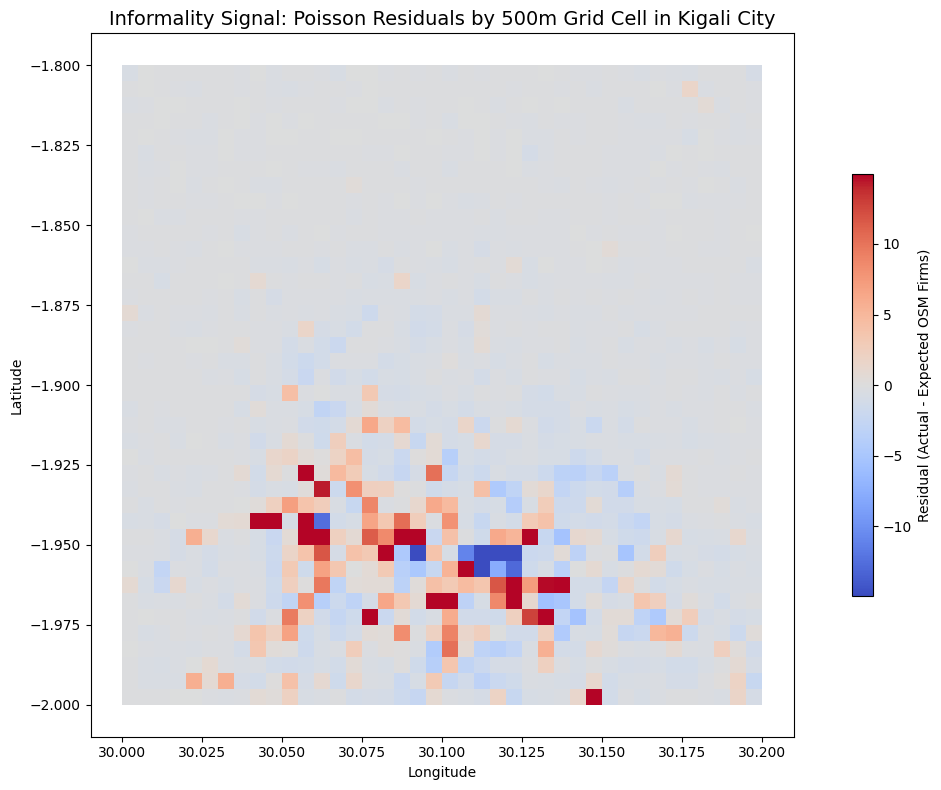

In [32]:
# Map: Residual (Informality Signal) (Grid)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
vmax = max(abs(grid_gdf['residual'].quantile(0.01)), abs(grid_gdf['residual'].quantile(0.99)))
grid_gdf.plot(column='residual', cmap='coolwarm', legend=True, ax=ax,
              legend_kwds={'label': 'Residual (Actual - Expected OSM Firms)', 'shrink': 0.6},
              vmin=-vmax, vmax=vmax)
ax.set_title('Informality Signal: Poisson Residuals by 500m Grid Cell in Kigali City', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/outputs/maps/residual_informality_map.png", dpi=150)
plt.show()

### 15e: Map Enhanced Clusters (Firms)

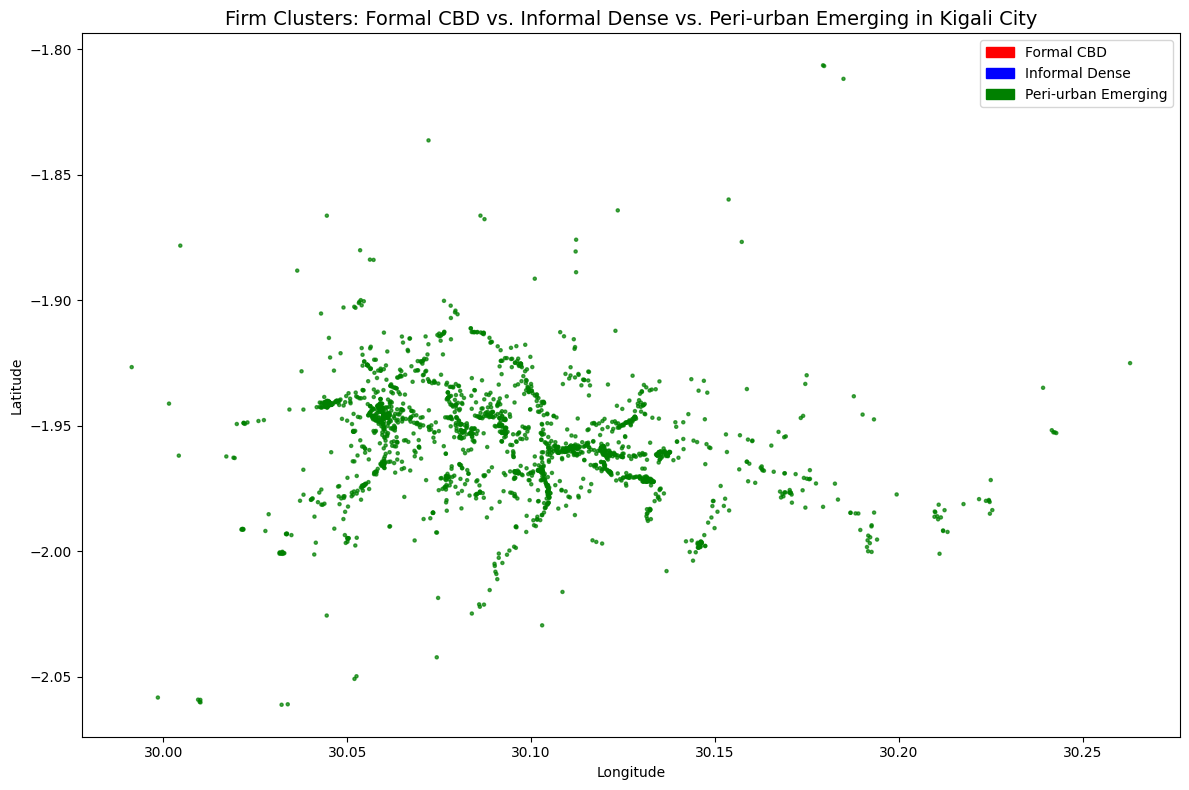

In [34]:
# Map: Enhanced Clusters (Firms)

import matplotlib.patches as mpatches

cluster_colors = {'Formal CBD': 'red', 'Informal Dense': 'blue', 'Peri-urban Emerging': 'green'}
firms_enriched['color'] = firms_enriched['cluster_label'].map(cluster_colors)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.scatter(firms_enriched['lon'], firms_enriched['lat'], c=firms_enriched['color'], s=5, alpha=0.7)
patches = [mpatches.Patch(color=c, label=l) for l, c in cluster_colors.items()]
ax.legend(handles=patches, loc='upper right')
ax.set_title('Firm Clusters: Formal CBD vs. Informal Dense vs. Peri-urban Emerging in Kigali City', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/outputs/maps/enhanced_clusters_map.png", dpi=150)
plt.show()

### 15f: Scatter Plot: OSM extracted Firms vs. Expected Firms

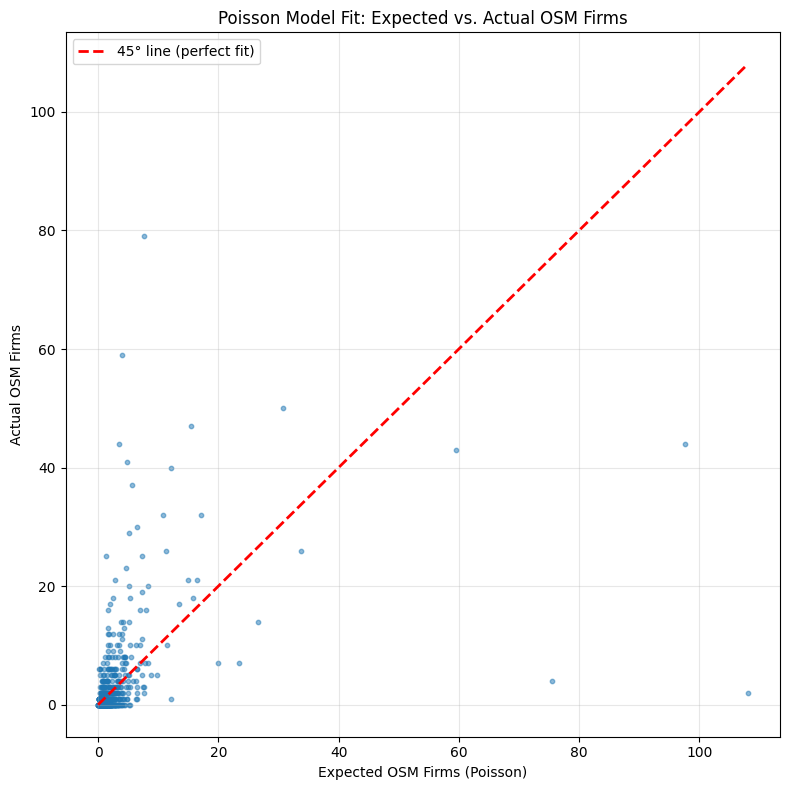

In [35]:
# Scatter: OSM Firms vs. Expected Firms (Grid)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(grid_gdf['expected_osm_firms'], grid_gdf['osm_firm_count'], alpha=0.5, s=10)
ax.plot([0, grid_gdf['expected_osm_firms'].max()], [0, grid_gdf['expected_osm_firms'].max()], 'r--', lw=2, label='45° line (perfect fit)')
ax.set_xlabel('Expected OSM Firms (Poisson)')
ax.set_ylabel('Actual OSM Firms')
ax.set_title('Poisson Model Fit: Expected vs. Actual OSM Firms')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/outputs/figures/poisson_fit_scatter.png", dpi=150)
plt.show()

### 15g: Bar Chart: Firm Type Composition by Cluster

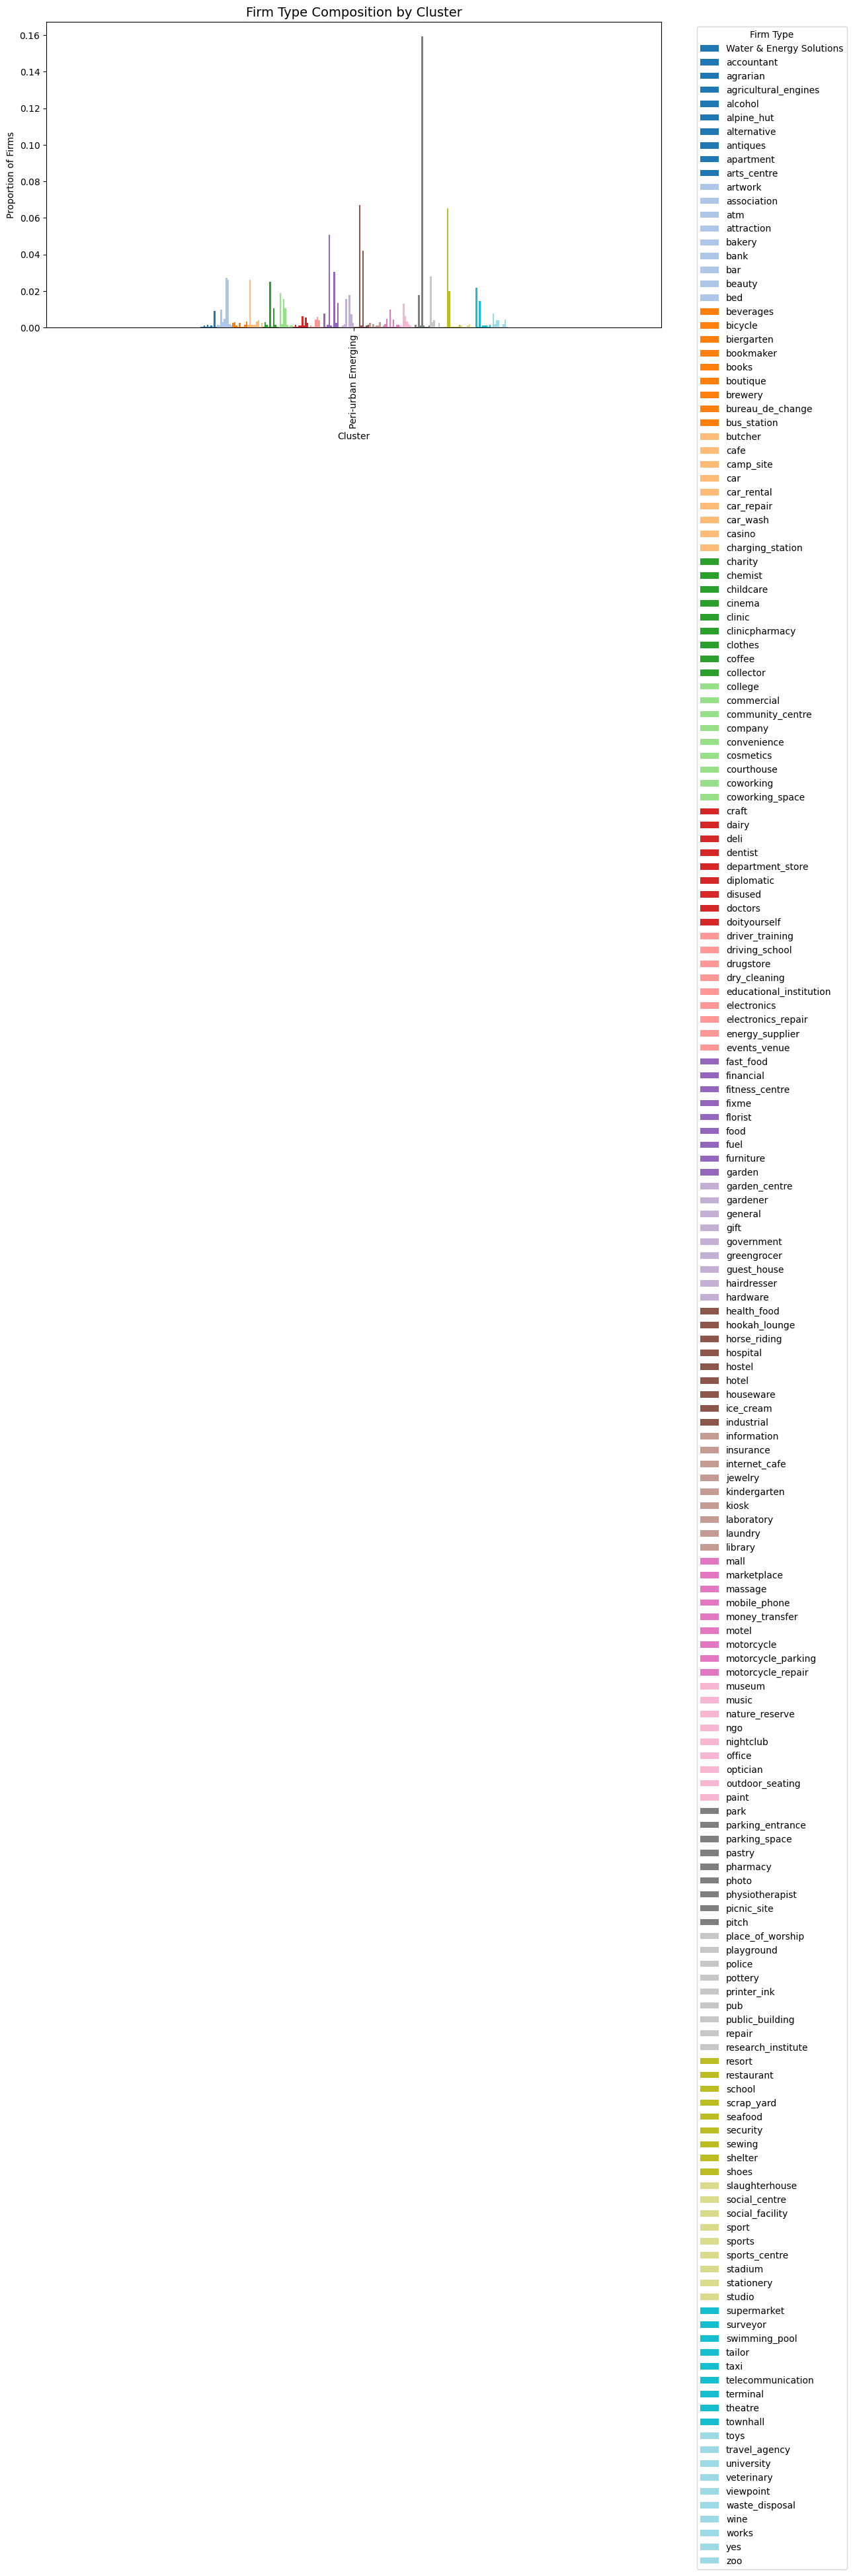

In [36]:
# Bar Chart to show Firm Type Composition by Cluster

type_by_cluster = firms_enriched.groupby(['cluster_label', 'type']).size().unstack(fill_value=0)
type_by_cluster_prop = type_by_cluster.div(type_by_cluster.sum(axis=1), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
type_by_cluster_prop.plot(kind='bar', ax=ax, colormap='tab20')
ax.set_title('Firm Type Composition by Cluster', fontsize=14)
ax.set_xlabel('Cluster')
ax.set_ylabel('Proportion of Firms')
ax.legend(title='Firm Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/outputs/figures/type_composition_by_cluster.png", dpi=150)
plt.show()

### 15h: Correlation Placeholder for Manual Validation

In [37]:
# Manual Validation Correlation (Placeholder)

# This cell will be updated once manual business counts are collected.
# Expected input: CSV with columns 'cell_id', 'manual_count'
manual_path = f"{PROJECT_PATH}/data/processed/manual_validation_counts.csv"
if os.path.exists(manual_path):
    manual = pd.read_csv(manual_path)
    valid_df = grid_gdf.merge(manual, on='cell_id', how='inner')
    if len(valid_df) > 2:
        corr = valid_df['manual_count'].corr(valid_df['coverage_ratio'])
        print(f"Correlation (manual count vs. coverage ratio): {corr:.3f}")
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))
        ax.scatter(valid_df['coverage_ratio'], valid_df['manual_count'])
        ax.set_xlabel('Coverage Ratio')
        ax.set_ylabel('Manual Business Count')
        ax.set_title(f'Validation: r = {corr:.3f}')
        plt.savefig(f"{PROJECT_PATH}/outputs/figures/validation_correlation.png", dpi=150)
        plt.show()
    else:
        print("Insufficient validation data for correlation.")
else:
    print("Manual validation counts file not found. Placeholder active.")

Manual validation counts file not found. Placeholder active.


### 15i: Poisson Regression Table

In [38]:
# 15i. Publication-Ready Poisson Regression Table

coef_df = pd.DataFrame({
    'Variable': poisson_model.params.index,
    'Coefficient': poisson_model.params.values,
    'Std. Error': poisson_model.bse.values,
    'z-value': poisson_model.tvalues.values,
    'p-value': poisson_model.pvalues.values
})
coef_df.to_csv(f"{PROJECT_PATH}/outputs/tables/poisson_coefficients_formatted.csv", index=False)

# Print a clean LaTeX-style table
print(coef_df.to_string(index=False))

   Variable  Coefficient  Std. Error    z-value       p-value
      const    -1.184509    0.040475 -29.265382 2.861532e-188
nightlights     0.070246    0.000891  78.875127  0.000000e+00
       ndbi     5.246949    0.211736  24.780676 1.448535e-135


### 15j: Interpretation of Key Results

## Interpretation of Key Results

### Poisson Regression
Both `nightlights` and `ndbi` are strongly positive and significant (p < 0.001). This confirms that satellite-observed economic activity (lights and built-up density) predicts OSM firm presence. The residual map highlights areas where OSM under-records firms relative to this expectation, our candidate informal zones.

### Clusters
- **Formal CBD**: High PC1, high coverage ratio. Central business district with dense formal mapping.
- **Informal Dense**: Moderate PC1, low coverage ratio. Active areas where OSM misses many firms (e.g., Nyamirambo, Biryogo).
- **Peri-urban Emerging**: Negative PC1, moderate coverage. Outskirts with low current activity but some formal presence.

### Validation
Cells containing OSM `marketplace` tags have a coverage ratio of 4.07 vs. 0.45 elsewhere, confirming that known formal markets are well-mapped while other commercial areas are under-represented.

### Limitations
NDBI missingness (67%) weakens the reliability of the composite PC1. The upcoming future work will refine cloud masking and consider spatial interpolation or alternative built-up proxies.

## 16. Marketplace Comparison

In [39]:
if 'marketplace' in firms_df['type'].unique():
    market_firms = firms_df[firms_df['type'] == 'marketplace']
    market_gdf = gpd.GeoDataFrame(market_firms, geometry=gpd.points_from_xy(market_firms.lon, market_firms.lat), crs="EPSG:4326")
    market_cells = gpd.sjoin(market_gdf, grid_gdf, how="inner", predicate="within")['cell_id'].unique()
    grid_gdf['has_market'] = grid_gdf['cell_id'].isin(market_cells)
    market_cov = grid_gdf[grid_gdf['has_market']]['coverage_ratio'].mean()
    other_cov = grid_gdf[~grid_gdf['has_market']]['coverage_ratio'].mean()
    print(f"Market cells mean coverage: {market_cov:.3f}")
    print(f"Other cells mean coverage: {other_cov:.3f}")

Market cells mean coverage: 4.054
Other cells mean coverage: 0.446


## 17. Export Summary Tables

In [40]:
cluster_summary = firms_enriched.groupby('cluster_label').agg({
    'econ_intensity_pc1': ['mean','std'],
    'coverage_ratio': ['mean','std'],
    'avg_nightlights': 'mean',
    'avg_ndbi': 'mean',
    'type': 'count'
}).round(3)
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns]
cluster_summary.to_csv(f"{PROJECT_PATH}/outputs/tables/cluster_summary.csv")

coef_df = pd.DataFrame({
    'coef': poisson_model.params,
    'std_err': poisson_model.bse,
    'z': poisson_model.tvalues,
    'p': poisson_model.pvalues
})
coef_df.to_csv(f"{PROJECT_PATH}/outputs/tables/poisson_coefficients.csv")

print("Phase 2 complete. All outputs saved.")

Phase 2 complete. All outputs saved.
